# Optuna NSGA-II Optimization (CUDA)

This notebook runs the full Optuna NSGA-II optimization on CIFAR-10 and Fashion-MNIST using the project objective definitions and search space.

In [1]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import torch

from data_loader import DEVICE
from moo_optuna import run_optuna_study

if DEVICE.type != "cuda":
    raise RuntimeError("CUDA is required for this notebook. Activate the project CUDA venv and rerun.")

print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.6.0+cu124
Device: cuda
GPU: NVIDIA GeForce GTX 1650


d:\forKrishna\MOML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
N_TRIALS = 100
TRAIN_SUBSET_SIZE = 20_000
POPULATION_SIZE = 24
SEED = 42
OUTPUT_ROOT = "results/optuna"
DATASETS = ["fashion_mnist"]

print(f"Trials per dataset   : {N_TRIALS}")
print(f"Train subset / trial : {TRAIN_SUBSET_SIZE:,}")
print(f"Population size       : {POPULATION_SIZE}")
print(f"Datasets              : {DATASETS}")

Trials per dataset   : 100
Train subset / trial : 20,000
Population size       : 24
Datasets              : ['fashion_mnist']


In [3]:
study_results = {}

for dataset_name in DATASETS:
    result = run_optuna_study(
        dataset_name=dataset_name,
        n_trials=N_TRIALS,
        train_subset_size=TRAIN_SUBSET_SIZE,
        seed=SEED,
        population_size=POPULATION_SIZE,
        output_root=OUTPUT_ROOT,
    )
    study_results[dataset_name] = result

print("All Optuna runs finished.")

[I 2026-04-24 17:39:31,768] A new study created in RDB with name: optuna_nsga2_fashion_mnist_20260424_173928
d:\forKrishna\MOML\moo_optuna.py:225: ExperimentalWarning: optuna.study.study.Study.set_metric_names is experimental (supported from v3.2.0). The interface can change in the future.
  study.set_metric_names(list(OBJECTIVE_NAMES))
[I 2026-04-24 17:41:52,558] Trial 0 finished with values: {'accuracy': 0.8822, 'inference_ms': 3.5100133999958416, 'param_count': 1280778.0} and parameters: {'arch_type': 'residual', 'num_conv_layers': 3, 'num_channels': 64, 'num_fc_units': 192, 'learning_rate': 1.1527987128232396e-05, 'batch_size': 16, 'num_epochs': 7, 'dropout_rate': 0.09170225492671691, 'optimizer_type': 'Adam', 'input_resolution': 16}.
[I 2026-04-24 17:44:13,162] Trial 1 finished with values: {'accuracy': 0.7353, 'inference_ms': 0.3998433999986446, 'param_count': 6282.0} and parameters: {'arch_type': 'plain', 'num_conv_layers': 2, 'num_channels': 16, 'num_fc_units': 32, 'learning_ra

All Optuna runs finished.


In [4]:
from pathlib import Path
import json

if "study_results" not in globals():
    study_results = {}

if "fashion_mnist" not in study_results:
    raise RuntimeError("Run Cell 4 first with DATASETS = ['fashion_mnist'].")

cifar_root = Path("results/optuna/cifar10")
if not cifar_root.exists():
    raise RuntimeError("CIFAR results folder not found.")

candidates = []
for run_dir in sorted(cifar_root.iterdir()):
    if not run_dir.is_dir():
        continue

    summary_path = run_dir / "summary.json"
    trials_csv = run_dir / "trials.csv"
    pareto_csv = run_dir / "pareto_front.csv"
    db_path = run_dir / "study.sqlite3"

    if not (summary_path.exists() and trials_csv.exists() and pareto_csv.exists() and db_path.exists()):
        continue

    try:
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
    except Exception:
        continue

    req = summary.get("n_trials_requested")
    comp = summary.get("n_trials_completed")
    if isinstance(req, int) and isinstance(comp, int) and comp >= req:
        candidates.append((run_dir, summary))

if not candidates:
    raise RuntimeError("No completed CIFAR run found with required artifacts.")

cifar_dir, cifar_summary = candidates[-1]

study_results["cifar10"] = {
        "study": None,
        "summary": cifar_summary,
        "paths": {
        "study_dir": str(cifar_dir),
        "storage": str(cifar_dir / "study.sqlite3"),
        "trials_csv": str(cifar_dir / "trials.csv"),
        "pareto_csv": str(cifar_dir / "pareto_front.csv"),
        "summary_json": str(cifar_dir / "summary.json"),
        },
    }

DATASETS = ["cifar10", "fashion_mnist"]

print("Loaded CIFAR from:", cifar_dir)
print("study_results keys:", list(study_results.keys()))
print("DATASETS:", DATASETS)    

Loaded CIFAR from: results\optuna\cifar10\optuna_nsga2_cifar10_20260424_112057
study_results keys: ['fashion_mnist', 'cifar10']
DATASETS: ['cifar10', 'fashion_mnist']


In [5]:
for dataset_name in DATASETS:
    summary = study_results[dataset_name]['summary']
    print(f"\n--- {dataset_name} ---")
    print(f"Study name         : {summary['study_name']}")
    print(f"Completed trials    : {summary['n_trials_completed']}")
    print(f"Pareto points       : {summary['n_pareto_points']}")
    print(f"Accuracy range      : {summary['accuracy_min']:.4f} - {summary['accuracy_max']:.4f}")
    print(f"Inference ms range  : {summary['inference_ms_min']:.4f} - {summary['inference_ms_max']:.4f}")
    print(f"Param count range   : {int(summary['param_count_min'])} - {int(summary['param_count_max'])}")
    print(f"Trials CSV          : {summary['artifacts']['trials_csv']}")
    print(f"Pareto CSV          : {summary['artifacts']['pareto_csv']}")


--- cifar10 ---
Study name         : optuna_nsga2_cifar10_20260424_112057
Completed trials    : 100
Pareto points       : 30
Accuracy range      : 0.1110 - 0.7895
Inference ms range  : 0.3994 - 41.1864
Param count range   : 2882 - 9912810
Trials CSV          : results\optuna\cifar10\optuna_nsga2_cifar10_20260424_112057\trials.csv
Pareto CSV          : results\optuna\cifar10\optuna_nsga2_cifar10_20260424_112057\pareto_front.csv

--- fashion_mnist ---
Study name         : optuna_nsga2_fashion_mnist_20260424_173928
Completed trials    : 100
Pareto points       : 30
Accuracy range      : 0.0936 - 0.9230
Inference ms range  : 0.2467 - 24.6590
Param count range   : 1322 - 9927242
Trials CSV          : results\optuna\fashion_mnist\optuna_nsga2_fashion_mnist_20260424_173928\trials.csv
Pareto CSV          : results\optuna\fashion_mnist\optuna_nsga2_fashion_mnist_20260424_173928\pareto_front.csv


## Pareto Metrics

Compute Pareto quality metrics after optimization and save them per study directory.

In [6]:
from pareto_analysis import DEFAULT_REFERENCE_POINT, evaluate_optuna_study_dir

metrics_results = {}

for dataset_name in DATASETS:
    study_dir = Path(study_results[dataset_name]["paths"]["study_dir"])
    metrics = evaluate_optuna_study_dir(
        study_dir=study_dir,
        reference_point=DEFAULT_REFERENCE_POINT,
        save_json=True,
    )
    metrics_results[dataset_name] = metrics

    print(f"\n--- Pareto metrics: {dataset_name} ---")
    print(f"Trials        : {metrics['n_trials']}")
    print(f"Pareto points : {metrics['n_pareto_points']}")
    print(f"Hypervolume   : {metrics['hypervolume']:.6f}")
    print(f"Spacing       : {metrics['spacing']:.6f}")
    print(f"Saved JSON    : {metrics['metrics_json']}")


--- Pareto metrics: cifar10 ---
Trials        : 100
Pareto points : 30
Hypervolume   : 7587879859.205417
Spacing       : 0.325355
Saved JSON    : results\optuna\cifar10\optuna_nsga2_cifar10_20260424_112057\pareto_metrics.json

--- Pareto metrics: fashion_mnist ---
Trials        : 100
Pareto points : 30
Hypervolume   : 9096255108.819237
Spacing       : 0.109626
Saved JSON    : results\optuna\fashion_mnist\optuna_nsga2_fashion_mnist_20260424_173928\pareto_metrics.json


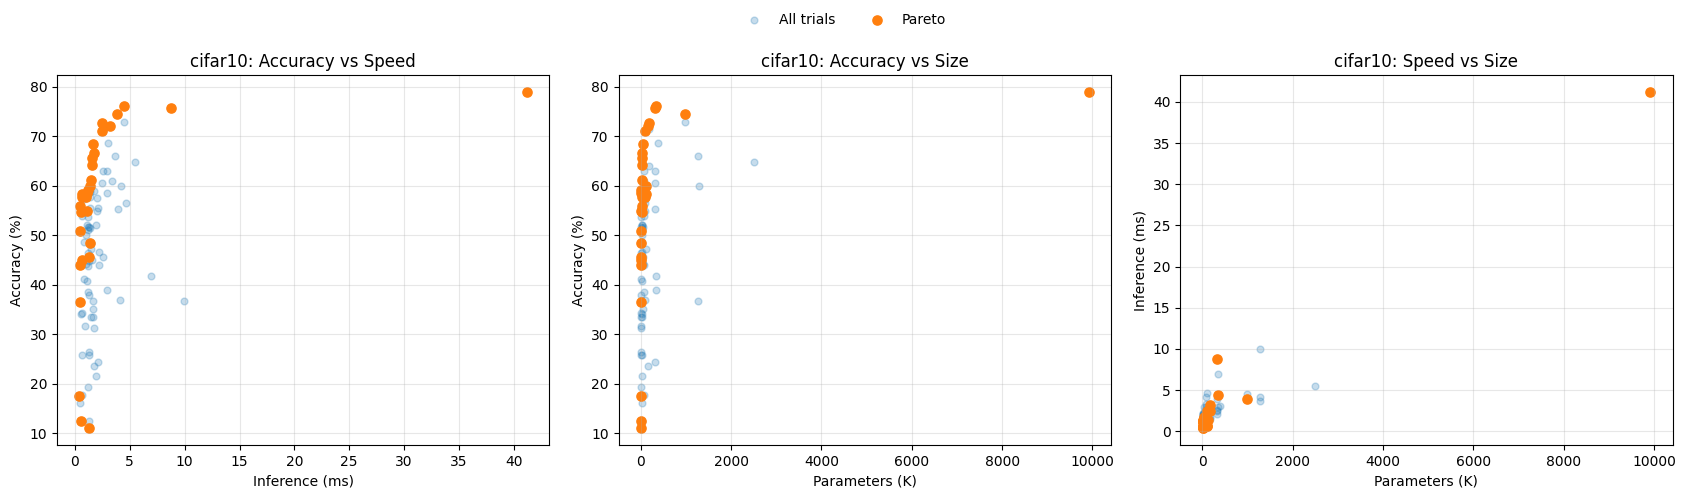

Saved plot: results\optuna\cifar10\optuna_nsga2_cifar10_20260424_112057\pareto_plots.png


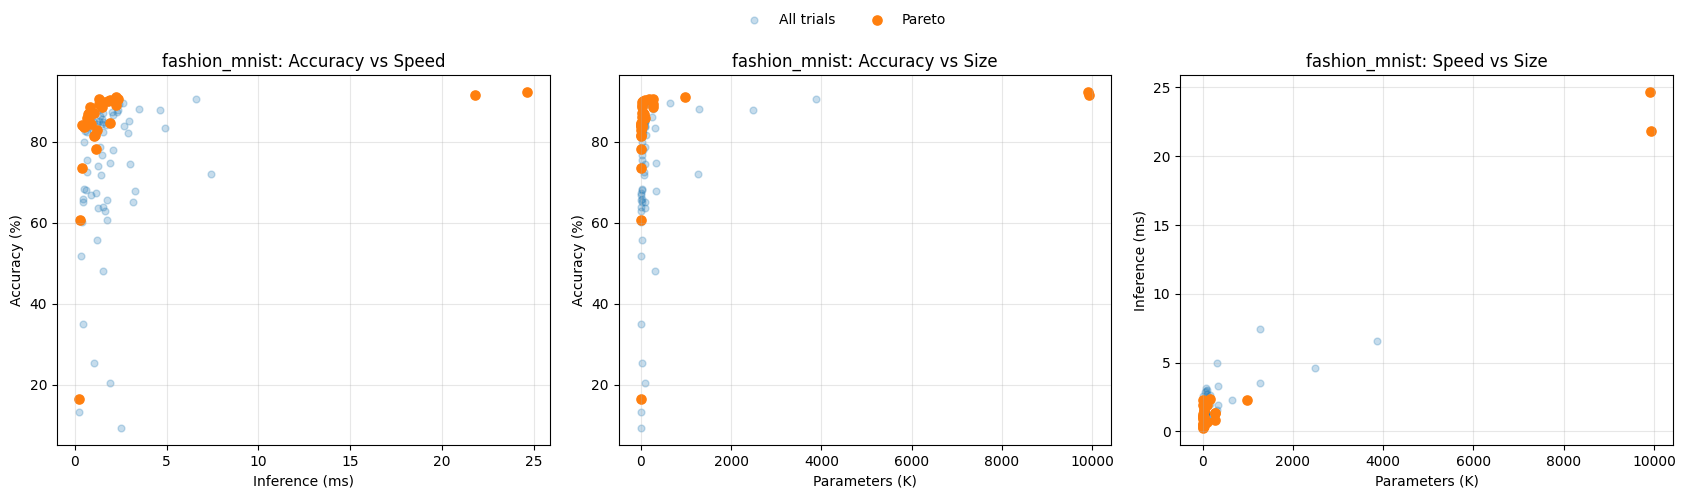

Saved plot: results\optuna\fashion_mnist\optuna_nsga2_fashion_mnist_20260424_173928\pareto_plots.png


In [7]:
def load_rows(csv_path: str):
    rows = []
    with open(csv_path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            row['accuracy'] = float(row['accuracy'])
            row['inference_ms'] = float(row['inference_ms'])
            row['param_count'] = float(row['param_count'])
            rows.append(row)
    return rows

for dataset_name in DATASETS:
    result = study_results[dataset_name]
    trials_rows = load_rows(result['paths']['trials_csv'])
    pareto_rows = load_rows(result['paths']['pareto_csv'])

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    axes[0].scatter([r['inference_ms'] for r in trials_rows], [r['accuracy'] * 100.0 for r in trials_rows], alpha=0.25, s=24, label='All trials')
    axes[0].scatter([r['inference_ms'] for r in pareto_rows], [r['accuracy'] * 100.0 for r in pareto_rows], s=44, label='Pareto')
    axes[0].set_xlabel('Inference (ms)')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title(f'{dataset_name}: Accuracy vs Speed')
    axes[0].grid(alpha=0.3)

    axes[1].scatter([r['param_count'] / 1000.0 for r in trials_rows], [r['accuracy'] * 100.0 for r in trials_rows], alpha=0.25, s=24, label='All trials')
    axes[1].scatter([r['param_count'] / 1000.0 for r in pareto_rows], [r['accuracy'] * 100.0 for r in pareto_rows], s=44, label='Pareto')
    axes[1].set_xlabel('Parameters (K)')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{dataset_name}: Accuracy vs Size')
    axes[1].grid(alpha=0.3)

    axes[2].scatter([r['param_count'] / 1000.0 for r in trials_rows], [r['inference_ms'] for r in trials_rows], alpha=0.25, s=24, label='All trials')
    axes[2].scatter([r['param_count'] / 1000.0 for r in pareto_rows], [r['inference_ms'] for r in pareto_rows], s=44, label='Pareto')
    axes[2].set_xlabel('Parameters (K)')
    axes[2].set_ylabel('Inference (ms)')
    axes[2].set_title(f'{dataset_name}: Speed vs Size')
    axes[2].grid(alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
    fig.tight_layout(rect=(0, 0, 1, 0.93))

    out_path = Path(result['paths']['study_dir']) / 'pareto_plots.png'
    fig.savefig(str(out_path), dpi=220, bbox_inches='tight')
    plt.show()
    print(f"Saved plot: {out_path}")

After completion, use the generated trials and Pareto CSV files for analysis/reporting.